In [ ]:
import torch
input_ids = torch.tensor([2,3,5,1])

vocab_size = 6
output_dimen = 3

torch.manual_seed(123)

embedding_layer = torch.nn.Embedding(vocab_size, output_dimen)
embedding_layer.weight

# When I send a question, the model will convert the question into tokens and then into embeddings Ids
# The embeddings ids are positions of tensors that have the embbedings that are stored based on the vocab size and the output dimension that I have defined when I created the embedding layer.

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


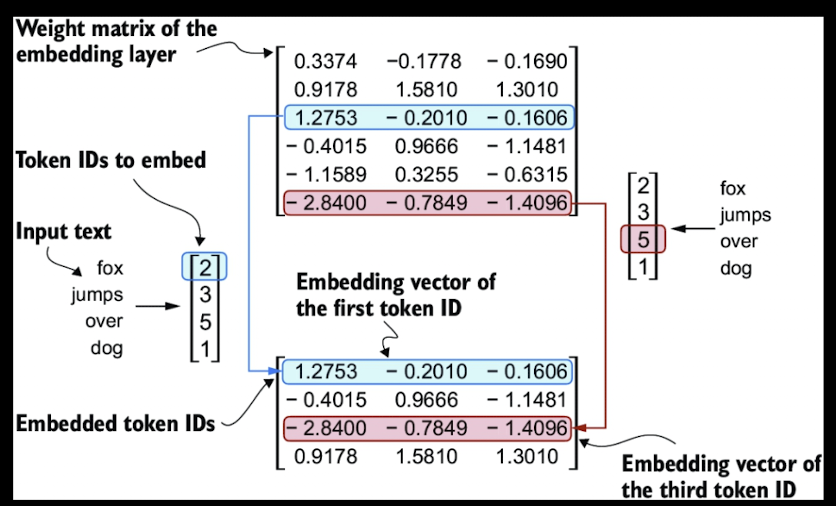

In [7]:
print(embedding_layer(torch.tensor([3])))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


## GPT embbedings IDs

Previously, we focused on very small embedding sizes for simplicity. Now, let’s consider more realistic and useful embedding sizes and encode the input tokens into a 256-dimensional vector representation, which is smaller than what the original GPT-3 model used (in GPT-3, the embedding size is 12,288 dimensions) but still reasonable for experimentation. Furthermore, we assume that the token IDs were created by the BPE tokenizer we implemented earlier, which has a vocabulary size of 50,257:

Raschka, Sebastian. Build a Large Language Model (From Scratch) (p. 101). (Function). Kindle Edition. 

In [4]:
import torch

vocab_size = 50257
output_dim = 256
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

/Users/zero101010/Docs/build-llm-from-scratch/.venv/lib/python3.14/site-packages/torch/_subclasses/functional_tensor.py:362: UserWarning: Failed to initialize NumPy: No module named 'numpy' (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:84.)
  cpu = _conversion_method_template(device=torch.device("cpu"))


In [6]:
# Dataloader

import torch

from torch.utils.data import Dataset, DataLoader


class GPTDatasetv1(Dataset):
    def __init__(self, txt, tokenizer, stride, max_length=512):
        self.input_ids = []
        self.target_ids = []
        token_ids = tokenizer.encode(txt)

        for i in range(0, len(token_ids) - max_length, stride):
            self.input_ids.append(token_ids[i : i + max_length])
            self.target_ids.append(token_ids[i + 1 : i + max_length + 1])

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        x = self.input_ids[idx]
        y = self.target_ids[idx]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

def create_dataloader_v1(txt,batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
    tiktokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetv1(txt, tiktokenizer, stride, max_length)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)
    return dataloader



In [9]:
import requests
import tiktoken
max_length = 4

url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

raw_text = requests.get(url).text
dataloader = create_dataloader_v1(raw_text,batch_size=8, max_length=max_length, stride=max_length, shuffle=False, drop_last=True)

data_iter = iter(dataloader)
inputs , targets = next(data_iter)
print("Inputs:\n", inputs)
print("Targets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])
Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


In [11]:
token_embeddings = token_embedding_layer(inputs)
print("Token Embeddings Shape:", token_embeddings.shape)
print("Token Embeddings:\n", token_embeddings)

Token Embeddings Shape: torch.Size([8, 4, 256])
Token Embeddings:
 tensor([[[-0.5475,  0.7542, -1.7613,  ..., -0.0523, -1.8865, -0.0711],
         [ 0.4702, -0.4864, -0.3254,  ..., -1.5797, -0.2646,  0.1199],
         [-0.5557, -0.2072,  0.3466,  ...,  0.6108, -1.9939,  0.8271],
         [ 0.2753,  0.7323,  0.9767,  ..., -0.4659,  0.9298, -0.3241]],

        [[-2.0652,  1.2211,  0.1676,  ...,  0.1781, -0.4778,  0.0943],
         [ 0.4835, -0.1757,  0.7072,  ..., -1.3910,  1.7801,  0.9798],
         [-0.5284,  1.4536, -2.0467,  ...,  0.9943,  1.2078, -0.6473],
         [-0.1303, -0.4831,  1.3987,  ..., -0.5176, -0.2523,  1.0539]],

        [[-0.6590,  2.4670, -0.4041,  ..., -0.5574,  2.0860,  1.4481],
         [-0.4766, -1.2030, -0.4829,  ...,  1.2347, -1.7718,  0.2915],
         [ 1.2856, -0.5000, -0.3555,  ...,  0.1088, -0.0536,  0.5301],
         [ 0.1476, -0.7143, -0.8153,  ..., -0.9991, -0.9690, -1.8822]],

        ...,

        [[ 0.1667,  0.4126, -1.5346,  ..., -0.1942, -0.6452, 

In [ ]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)
# Create positional embeddings for the input sequence
pos_embeddings = pos_embedding_layer(torch.arange(context_length))
print(pos_embeddings.shape)


torch.Size([4, 256])


In [16]:
input_embeddings = token_embeddings + pos_embeddings
print("Input Embeddings without positional:", token_embeddings[0])
print("Embeddings + Positional Embeddings:", input_embeddings[0])
print("Shape of Input Embeddings:", input_embeddings.shape)

Input Embeddings without positional: tensor([[-0.5475,  0.7542, -1.7613,  ..., -0.0523, -1.8865, -0.0711],
        [ 0.4702, -0.4864, -0.3254,  ..., -1.5797, -0.2646,  0.1199],
        [-0.5557, -0.2072,  0.3466,  ...,  0.6108, -1.9939,  0.8271],
        [ 0.2753,  0.7323,  0.9767,  ..., -0.4659,  0.9298, -0.3241]],
       grad_fn=<SelectBackward0>)
Embeddings + Positional Embeddings: tensor([[-1.2111,  0.8199, -2.6553,  ..., -0.0213, -2.8474,  1.0703],
        [-0.5951, -0.8419,  0.8001,  ...,  0.1517, -1.0642,  0.3184],
        [-0.8382,  0.5459,  0.3958,  ...,  0.7929, -1.6455,  2.5727],
        [ 1.8835,  0.8412, -0.0309,  ..., -0.3432,  3.6901, -0.9258]],
       grad_fn=<SelectBackward0>)
Shape of Input Embeddings: torch.Size([8, 4, 256])
